
# Aggregated Dataset Validation & Exploratory Data Analysis

This notebook:

- Validates dataset integrity
- Verifies date continuity
- Builds and validates targets
- Explores temporal patterns
- Analyzes relationships between targets, weather, and calendar features
- Computes feature-only correlation analyses


In [2]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels
from pathlib import Path

pd.set_option("display.max_columns", None)

DATA_PATH = Path("../../data/processed/aggregated_dataset.parquet")
df = pd.read_parquet(DATA_PATH)
print(df.shape)
df.head()


(2026, 64)


,avg_temperature(°C)_pohang,avg_temperature(°C)_seoul,min_temperature(°C)_pohang,min_temperature(°C)_seoul,max_temperature(°C)_pohang,max_temperature(°C)_seoul,precipitation_duration(hr)_pohang,precipitation_duration(hr)_seoul,daily_precipitation(mm)_pohang,daily_precipitation(mm)_seoul,max_gust_wind_speed(m/s)_pohang,max_gust_wind_speed(m/s)_seoul,max_wind_speed(m/s)_pohang,max_wind_speed(m/s)_seoul,avg_wind_speed(m/s)_pohang,avg_wind_speed(m/s)_seoul,avg_dew_point(°C)_pohang,avg_dew_point(°C)_seoul,min_relative_humidity(%)_pohang,min_relative_humidity(%)_seoul,avg_humidity(%)_pohang,avg_humidity(%)_seoul,avg_local_pressure(hPa)_pohang,avg_local_pressure(hPa)_seoul,max_sea_level_pressure(hPa)_pohang,max_sea_level_pressure(hPa)_seoul,min_sea_level_pressure(hPa)_pohang,min_sea_level_pressure(hPa)_seoul,avg_sea_level_pressure(hPa)_pohang,avg_sea_level_pressure(hPa)_seoul,sunshine_possible_hours_pohang,sunshine_possible_hours_seoul,total_sunshine_hours_pohang,total_sunshine_hours_seoul,total_solar_radiation(MJ/m2)_pohang,total_solar_radiation(MJ/m2)_seoul,daily_max_new_snow_depth(cm)_pohang,daily_max_new_snow_depth(cm)_seoul,avg_cloud_cover(1/10)_pohang,avg_cloud_cover(1/10)_seoul,fog_occured_pohang,fog_occured_seoul,most_frequent_wind_direction_sin_pohang,most_frequent_wind_direction_sin_seoul,most_frequent_wind_direction_cos_pohang,most_frequent_wind_direction_cos_seoul,rail_passengers_pohang_to_seoul,express_bus_passengers_pohang_to_seoul,intercity_bus_passengers_pohang_to_seoul,rail_passengers_seoul_to_pohang,express_bus_passengers_seoul_to_pohang,intercity_bus_passengers_seoul_to_pohang,day_of_month,month,year,day_of_week,is_weekend,cos_month,sin_month,cos_day,sin_day,days_since_last_holiday,days_until_next_holiday,upcoming_non_working_days
0,13.9,13.7,12.6,11.6,14.7,15.0,7.75,7.17,0.4,13.6,6.3,10.8,3.9,4.5,2.3,2.3,9.1,10.9,63.0,56.0,73.4,84.3,1020.3,1009.2,1023.8,1021.8,1018.9,1017.7,1020.8,1019.5,10.7,10.6,0.0,0.0,2.38,1.61,0.0,0.0,9.8,8.6,0,0,-0.766044,-0.342020,-6.427876e-01,-9.396926e-01,1173,514,34,1045,558,44,1,11,2020,7,1,0.866025,-0.5,1.000000,-2.449294e-16,23,54,0
1,14.2,10.8,10.0,7.9,18.2,15.6,0.00,2.33,0.0,1.7,5.2,8.7,3.5,4.9,2.1,2.3,3.8,1.7,26.0,24.0,52.0,58.3,1018.9,1010.1,1021.2,1022.3,1018.0,1019.1,1019.4,1020.4,10.7,10.6,3.9,9.6,9.07,14.60,0.0,0.0,6.5,3.0,0,0,-0.939693,-1.000000,-3.420201e-01,-1.836970e-16,831,330,26,853,353,39,2,11,2020,1,0,0.866025,-0.5,0.623490,7.818315e-01,24,53,0
2,8.5,5.1,5.1,2.7,12.1,8.6,0.00,0.83,0.0,0.5,11.1,15.6,7.1,8.4,3.1,3.5,-6.2,-5.4,17.0,33.0,37.0,47.5,1018.6,1011.9,1021.6,1024.1,1016.9,1019.6,1019.1,1022.5,10.6,10.6,9.7,9.2,14.54,15.22,0.0,0.0,0.8,1.5,0,0,-1.000000,-1.000000,-1.836970e-16,-1.836970e-16,701,292,28,688,313,32,3,11,2020,2,0,0.866025,-0.5,-0.222521,9.749279e-01,25,52,0
3,8.1,4.9,3.3,0.2,14.5,10.8,0.00,0.00,0.0,0.0,7.3,7.4,4.6,4.2,2.8,2.3,-11.4,-7.1,11.0,20.0,26.5,43.9,1023.1,1015.2,1025.4,1028.2,1021.3,1023.9,1023.6,1025.9,10.6,10.5,9.8,9.6,15.11,15.36,0.0,0.0,0.0,0.0,0,0,-0.939693,-1.000000,-3.420201e-01,-1.836970e-16,828,276,45,800,266,27,4,11,2020,3,0,0.866025,-0.5,-0.900969,4.338837e-01,26,51,0
4,11.6,9.6,4.5,3.4,18.4,15.9,0.00,0.00,0.0,0.0,6.3,4.5,4.9,3.0,2.3,1.8,-3.2,2.3,20.0,41.0,35.8,61.5,1026.2,1016.7,1028.8,1029.1,1025.1,1025.2,1026.7,1027.2,10.6,10.5,9.5,8.4,13.84,12.77,0.0,0.0,4.3,5.3,0,0,-0.766044,0.766044,-6.427876e-01,6.427876e-01,942,337,39,985,374,37,5,11,2020,4,0,0.866025,-0.5,-0.900969,-4.338837e-01,27,50,0


## Dataset Integrity Checks

In [3]:

print("Missing values")
display(df.isna().sum().sort_values(ascending=False).head(20))

print("\nDuplicate rows:", df.duplicated().sum())

numeric_cols = df.select_dtypes(include=np.number).columns
negative_counts = {c: int((df[c] < 0).sum()) for c in numeric_cols}
negative_counts = {k:v for k,v in negative_counts.items() if v > 0}
print("\nNegative values:")
negative_counts


Missing values


avg_temperature(°C)_pohang           0
avg_temperature(°C)_seoul            0
min_temperature(°C)_pohang           0
min_temperature(°C)_seoul            0
max_temperature(°C)_pohang           0
max_temperature(°C)_seoul            0
precipitation_duration(hr)_pohang    0
precipitation_duration(hr)_seoul     0
daily_precipitation(mm)_pohang       0
daily_precipitation(mm)_seoul        0
max_gust_wind_speed(m/s)_pohang      0
max_gust_wind_speed(m/s)_seoul       0
max_wind_speed(m/s)_pohang           0
max_wind_speed(m/s)_seoul            0
avg_wind_speed(m/s)_pohang           0
avg_wind_speed(m/s)_seoul            0
avg_dew_point(°C)_pohang             0
avg_dew_point(°C)_seoul              0
min_relative_humidity(%)_pohang      0
min_relative_humidity(%)_seoul       0
dtype: int64


Duplicate rows: 0

Negative values:


{'avg_temperature(°C)_pohang': 97,
 'avg_temperature(°C)_seoul': 267,
 'min_temperature(°C)_pohang': 276,
 'min_temperature(°C)_seoul': 488,
 'max_temperature(°C)_pohang': 18,
 'max_temperature(°C)_seoul': 104,
 'avg_dew_point(°C)_pohang': 616,
 'avg_dew_point(°C)_seoul': 678,
 'most_frequent_wind_direction_sin_pohang': 1446,
 'most_frequent_wind_direction_sin_seoul': 1135,
 'most_frequent_wind_direction_cos_pohang': 1366,
 'most_frequent_wind_direction_cos_seoul': 1001,
 'cos_month': 964,
 'sin_month': 981,
 'cos_day': 1157,
 'sin_day': 1157}

## Date Continuity Validation

In [4]:

required_date_cols = {"year", "month", "day_of_month"}

if required_date_cols.issubset(df.columns):
    df["date"] = pd.to_datetime(
        dict(year=df["year"], month=df["month"], day=df["day_of_month"])
    )

    full_range = pd.date_range(
        start=df["date"].min(),
        end=df["date"].max(),
        freq="D"
    )

    missing_dates = full_range.difference(df["date"])

    print("Date range:", df["date"].min(), "->", df["date"].max())
    print("Missing days:", len(missing_dates))

    if len(missing_dates):
        display(pd.Series(missing_dates, name="missing_dates"))


Date range: 2020-11-01 00:00:00 -> 2026-05-19 00:00:00
Missing days: 0


## Target Distributions

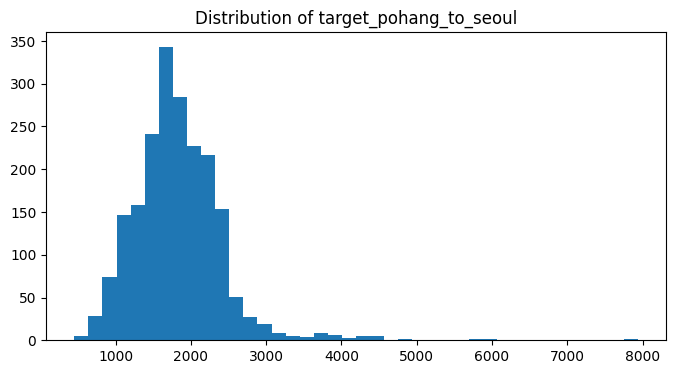

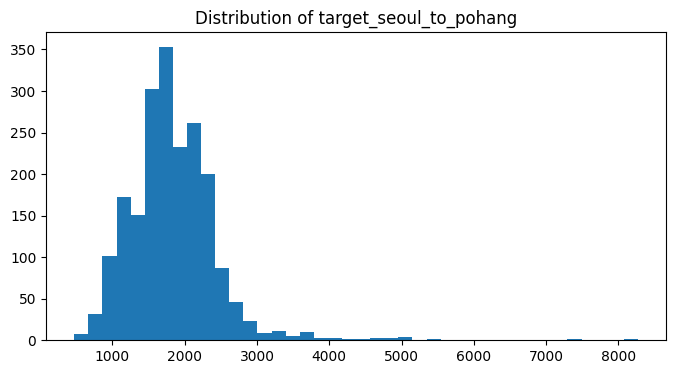

In [5]:
pohang_to_seoul_components = [
    "rail_passengers_pohang_to_seoul",
    "express_bus_passengers_pohang_to_seoul",
    "intercity_bus_passengers_pohang_to_seoul",
]

seoul_to_pohang_components = [
    "rail_passengers_seoul_to_pohang",
    "express_bus_passengers_seoul_to_pohang",
    "intercity_bus_passengers_seoul_to_pohang",
]

required_columns = pohang_to_seoul_components + seoul_to_pohang_components
missing_required = [c for c in required_columns if c not in df.columns]

if missing_required:
    raise ValueError(f"Colonnes manquantes pour construire les cibles: {missing_required}")

if "target_pohang_to_seoul" not in df.columns:
    df["target_pohang_to_seoul"] = df[pohang_to_seoul_components].sum(axis=1)

if "target_seoul_to_pohang" not in df.columns:
    df["target_seoul_to_pohang"] = df[seoul_to_pohang_components].sum(axis=1)


targets = [
    "target_pohang_to_seoul",
    "target_seoul_to_pohang"
]

for target in targets:
    if target in df.columns:
        plt.figure(figsize=(8,4))
        plt.hist(df[target].dropna(), bins=40)
        plt.title(f"Distribution of {target}")
        plt.show()


## Target Time Series (7D and 30D Rolling Means)

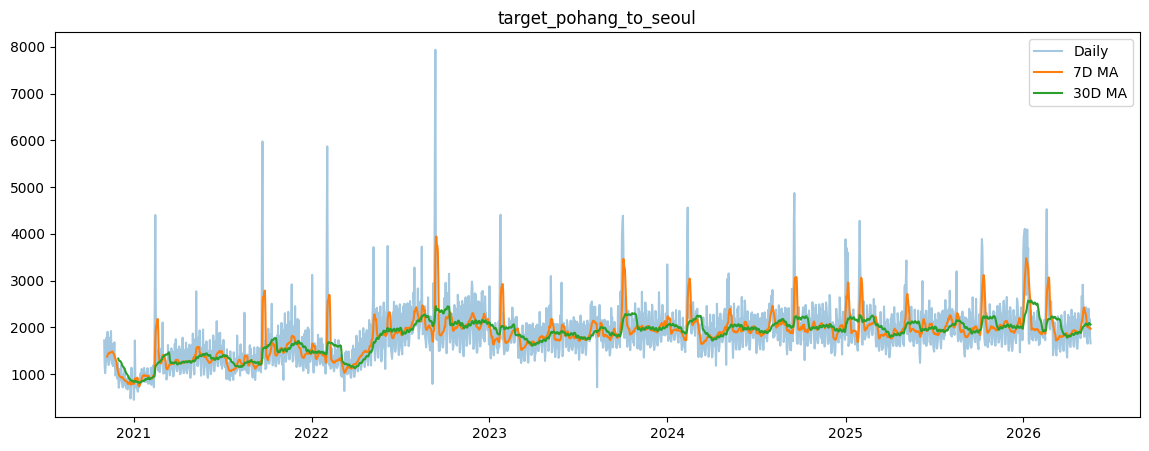

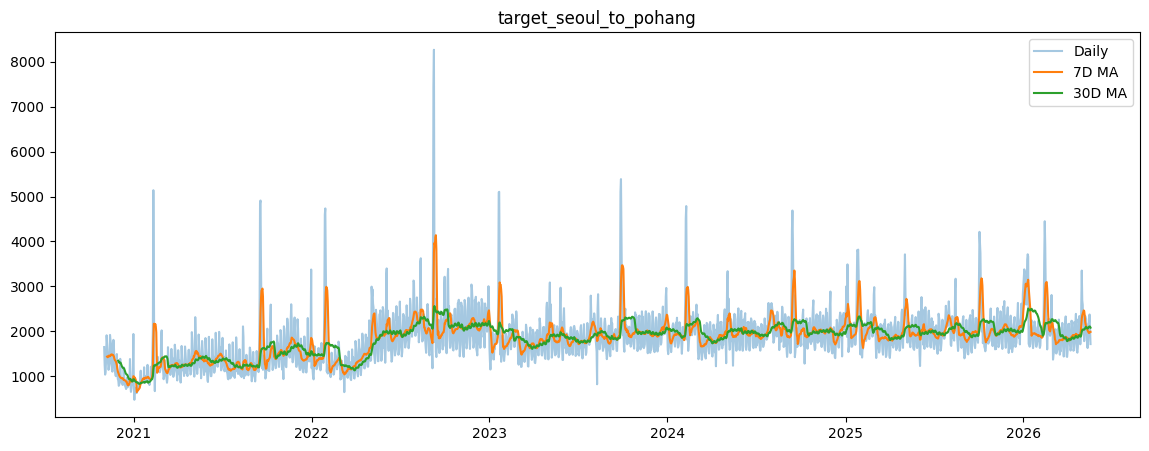

In [6]:

if "date" in df.columns:
    for target in targets:
        if target in df.columns:
            tmp = df.sort_values("date")

            plt.figure(figsize=(14,5))
            plt.plot(tmp["date"], tmp[target], alpha=0.4, label="Daily")
            plt.plot(tmp["date"], tmp[target].rolling(7).mean(), label="7D MA")
            plt.plot(tmp["date"], tmp[target].rolling(30).mean(), label="30D MA")
            plt.title(target)
            plt.legend()
            plt.show()


## Weather & Calendar Relationships

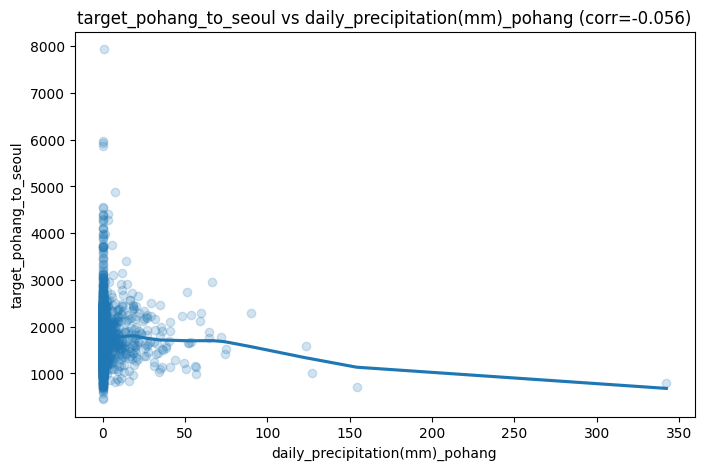

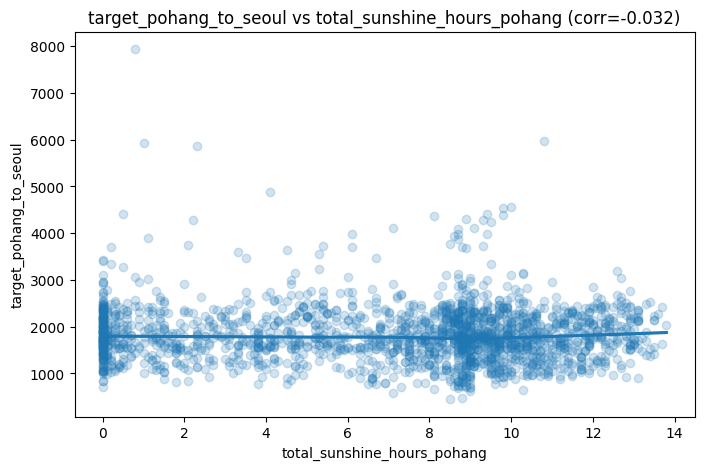

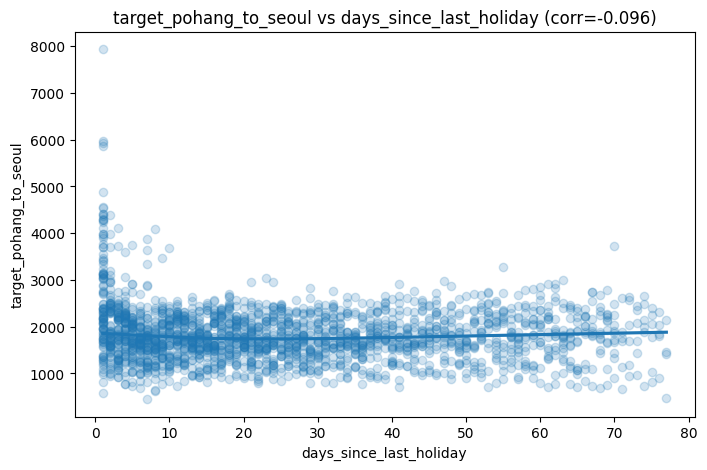

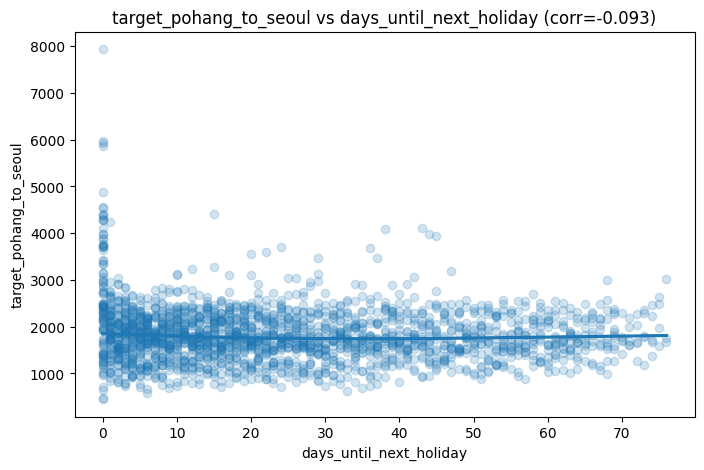

/home/jarva/anaconda3/envs/BusWeatherForecast/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


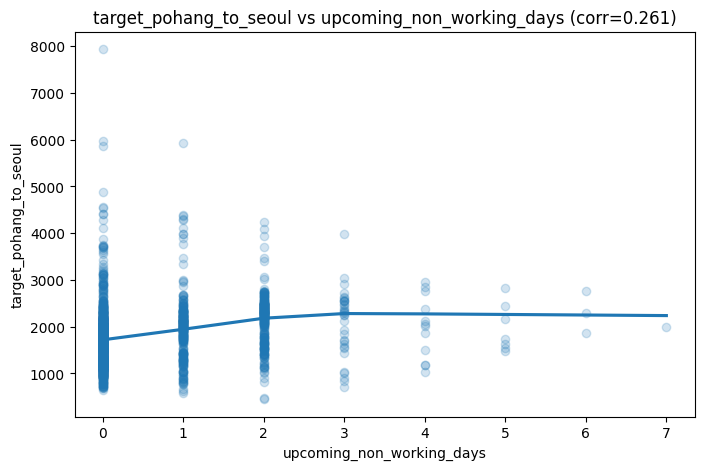

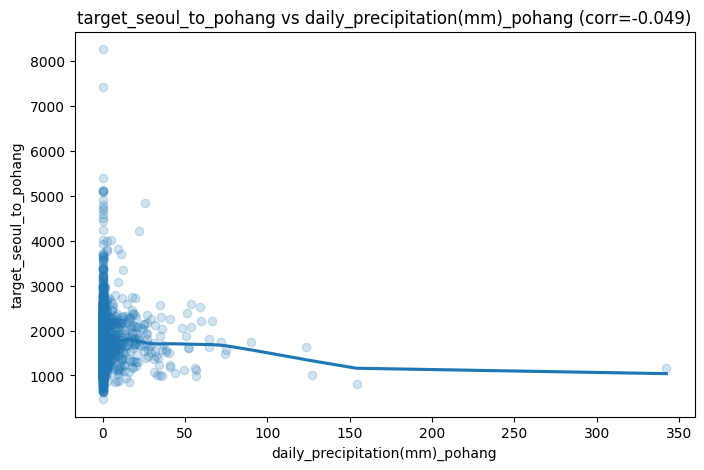

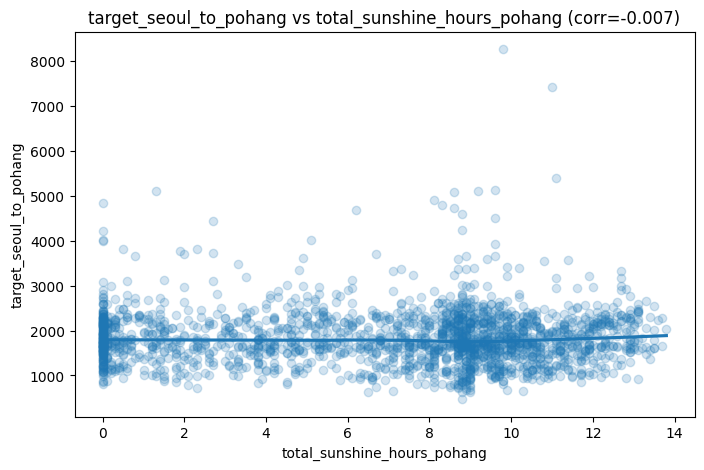

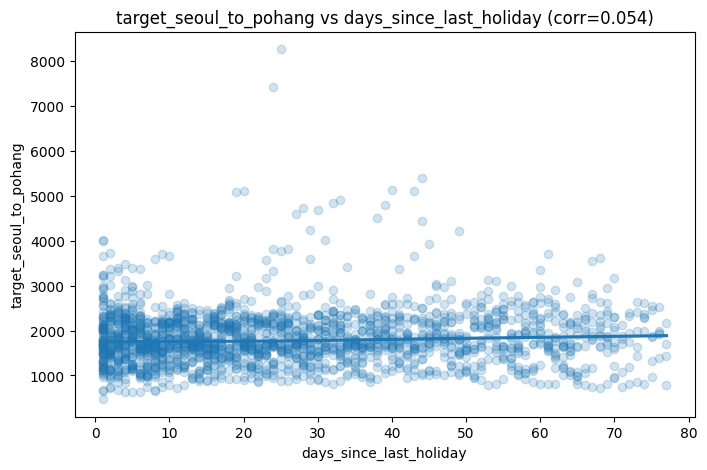

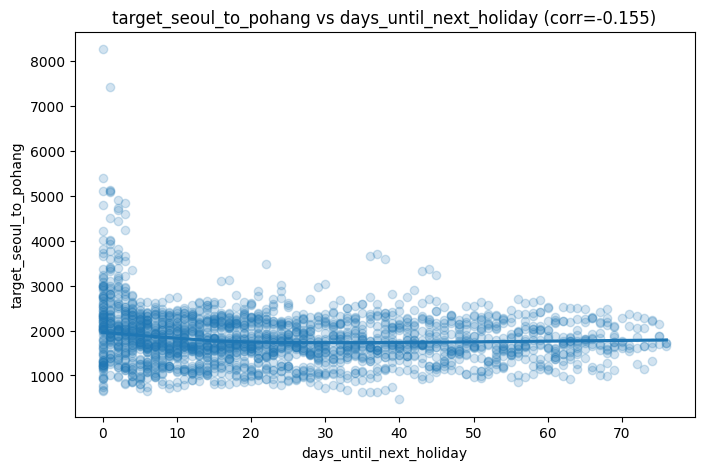

/home/jarva/anaconda3/envs/BusWeatherForecast/lib/python3.12/site-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


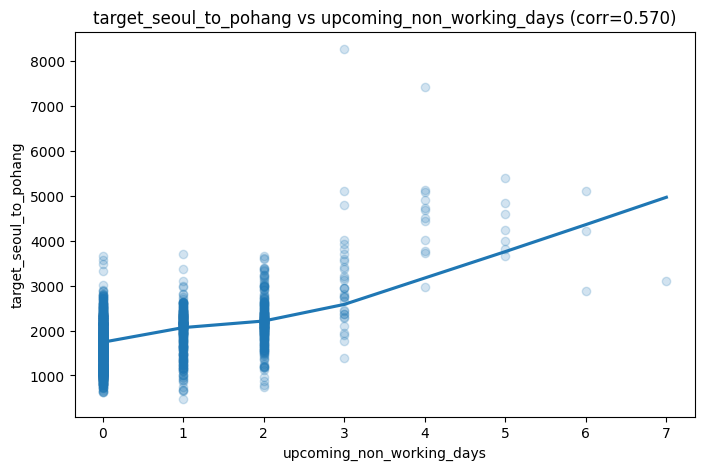

In [7]:

analysis_features = [
    "daily_precipitation(mm)_pohang",
    "wind_speed(m/s)_pohang",
    "total_sunshine_hours_pohang",
    "days_since_last_holiday",
    "days_until_next_holiday",
    "upcoming_non_working_days",
]

for target in targets:
    for feature in analysis_features:

        if feature in df.columns and target in df.columns:

            corr = df[[feature, target]].corr().iloc[0,1]

            plt.figure(figsize=(8,5))
            sns.regplot(
                data=df,
                x=feature,
                y=target,
                lowess=True,
                scatter_kws={"alpha":0.2}
            )
            plt.title(f"{target} vs {feature} (corr={corr:.3f})")
            plt.show()


## Day-of-Week Effect

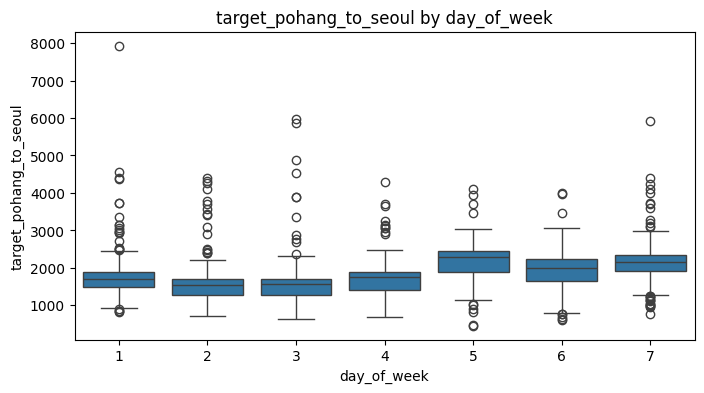

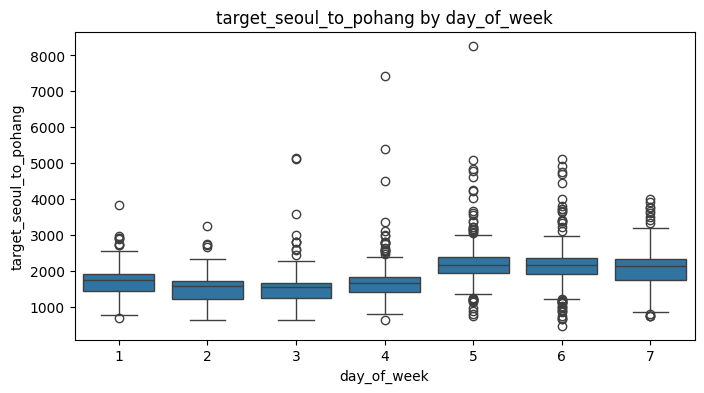

In [8]:

if "day_of_week" in df.columns:
    for target in targets:
        plt.figure(figsize=(8,4))
        sns.boxplot(data=df, x="day_of_week", y=target)
        plt.title(f"{target} by day_of_week")
        plt.show()


## Monthly Seasonality

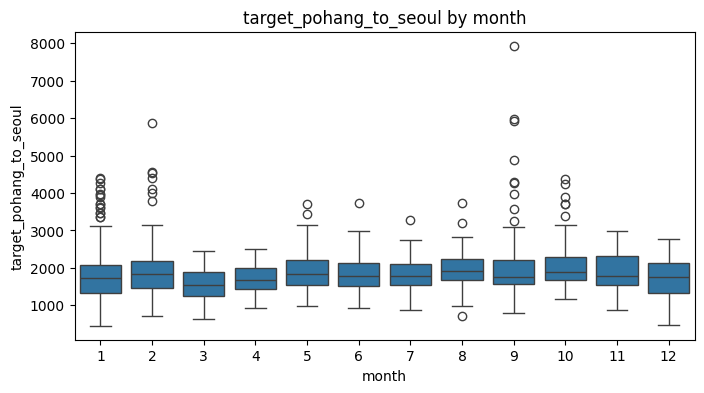

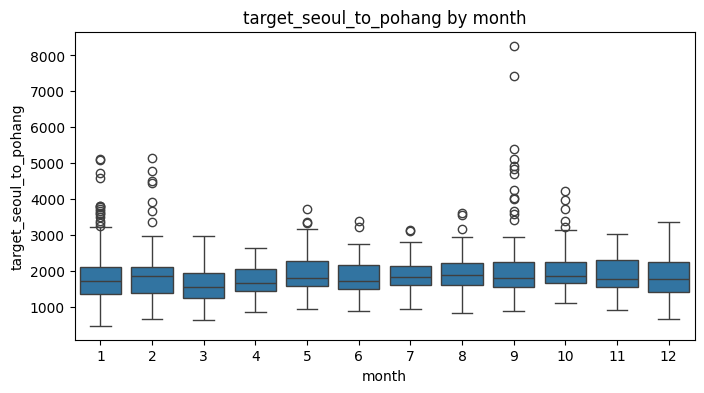

In [9]:

if "month" in df.columns:
    for target in targets:
        plt.figure(figsize=(8,4))
        sns.boxplot(data=df, x="month", y=target)
        plt.title(f"{target} by month")
        plt.show()


## Holiday vs Non-Holiday

is_holiday
False    1925
True      101
Name: count, dtype: int64


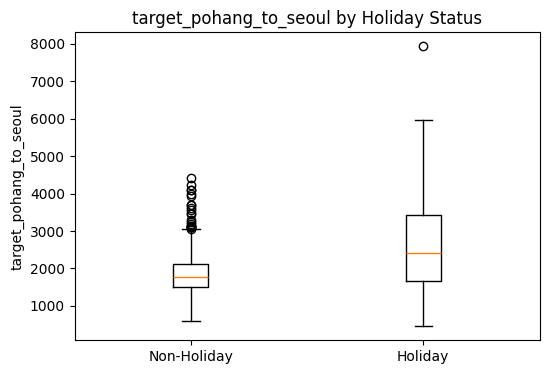

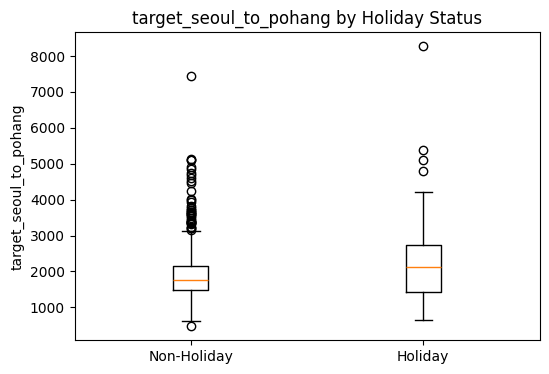

In [14]:
if {
    "days_since_last_holiday",
    "days_until_next_holiday"
}.issubset(df.columns):

    df["is_holiday"] = (
        (df["days_since_last_holiday"] == 0)
        | (df["days_until_next_holiday"] == 0)
    )

    print(df["is_holiday"].value_counts())

    for target in targets:

        plt.figure(figsize=(6, 4))

        holiday_values = df.loc[df["is_holiday"], target]
        non_holiday_values = df.loc[~df["is_holiday"], target]

        plt.boxplot(
            [non_holiday_values, holiday_values],
            tick_labels=["Non-Holiday", "Holiday"]
        )

        plt.title(f"{target} by Holiday Status")
        plt.ylabel(target)

        plt.show()


## Feature-Only Correlation Analysis

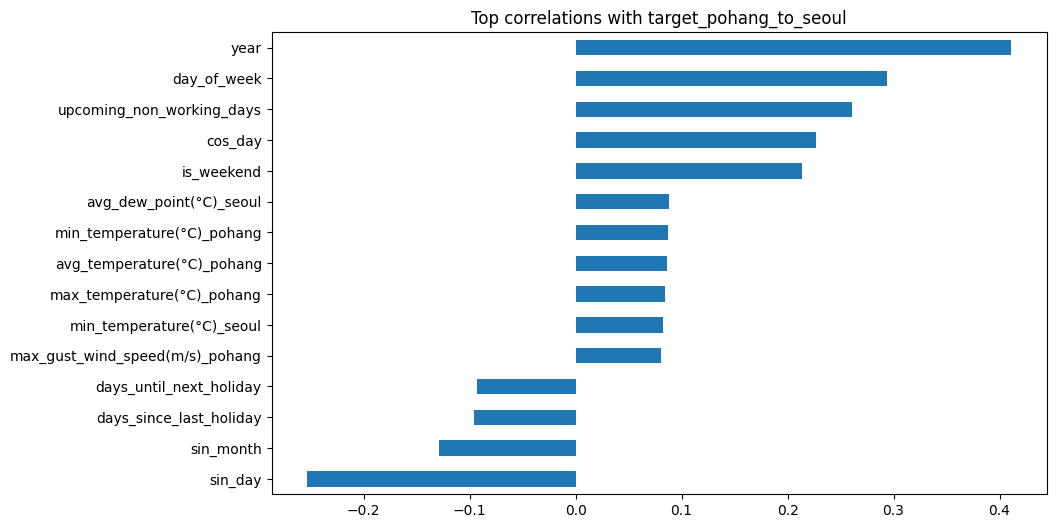

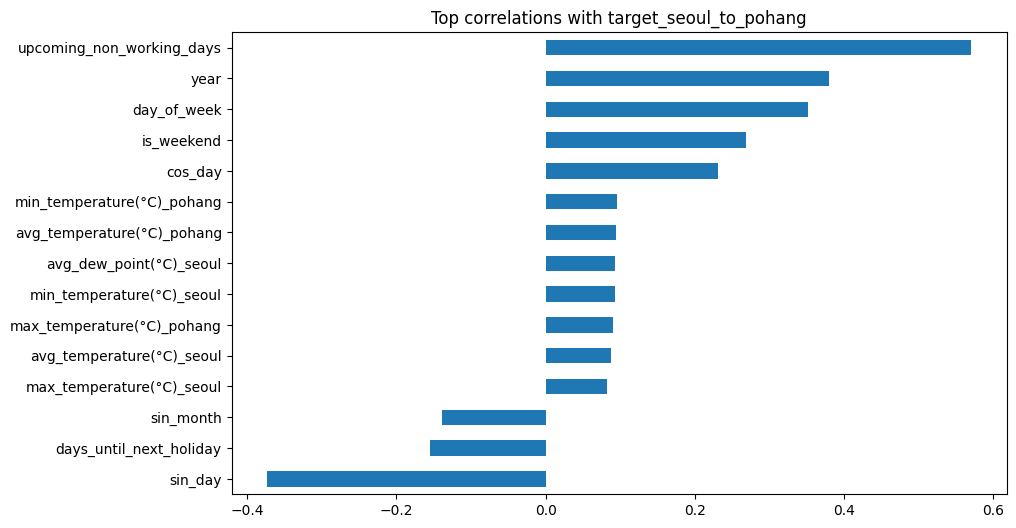

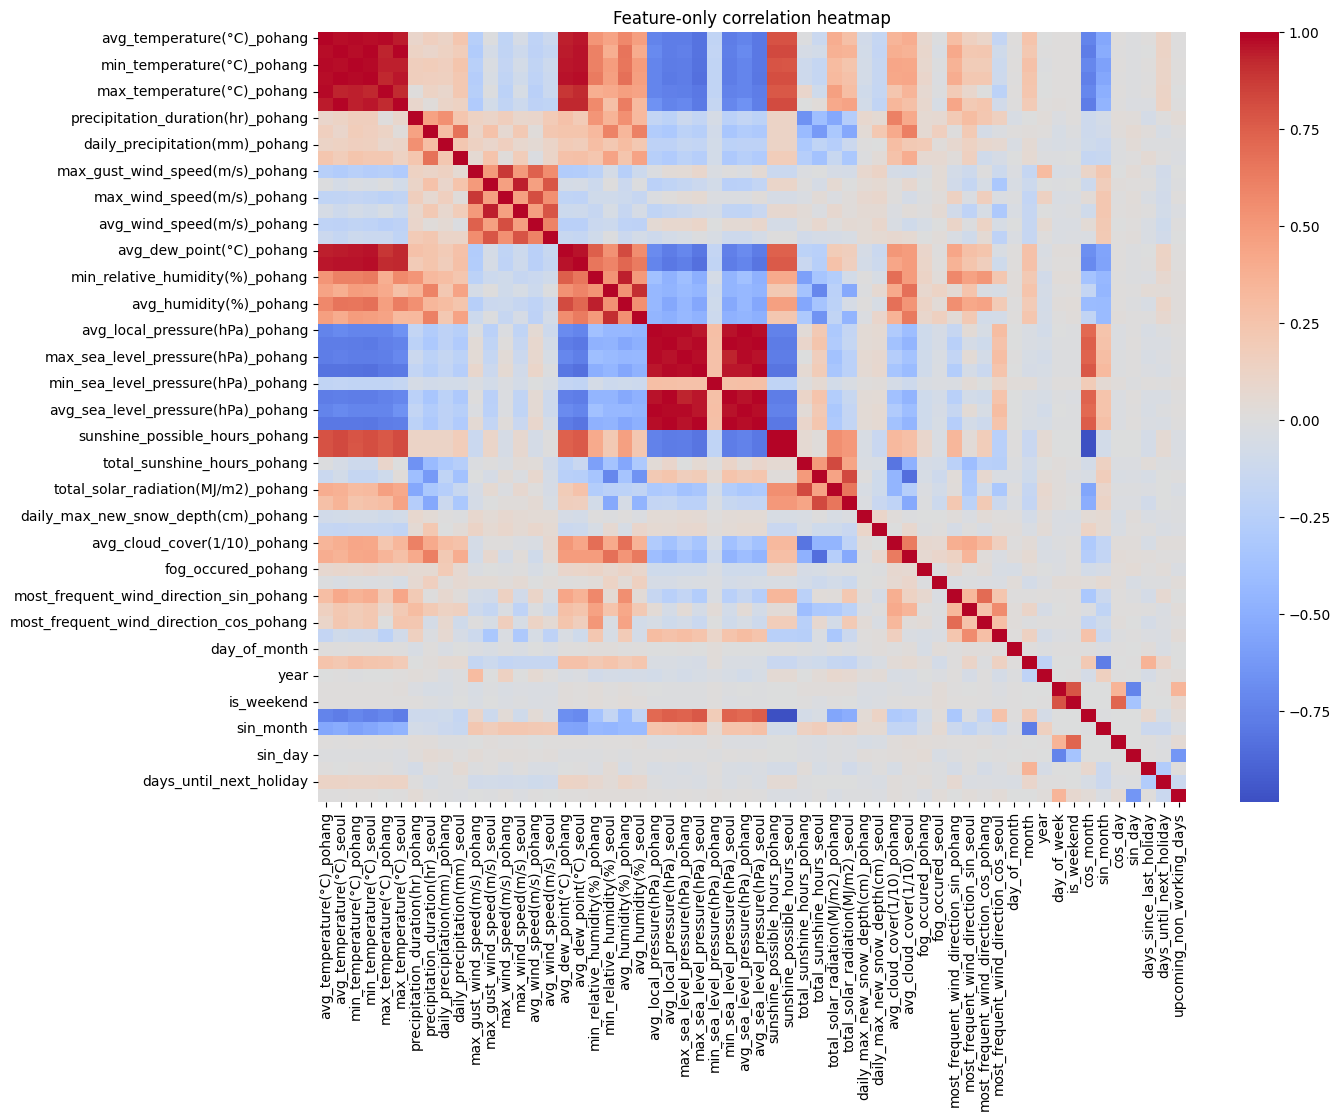

In [15]:

target_cols = [c for c in targets if c in df.columns]

feature_cols = [
    c for c in df.select_dtypes(include=np.number).columns
    if c not in pohang_to_seoul_components and c not in seoul_to_pohang_components and c not in target_cols
]

for target in target_cols:

    corr = (
        df[feature_cols]
        .corrwith(df[target])
        .dropna()
        .sort_values(key=np.abs, ascending=False)
        .head(15)
    )

    plt.figure(figsize=(10,6))
    corr.sort_values().plot(kind="barh")
    plt.title(f"Top correlations with {target}")
    plt.show()

corr_matrix = df[feature_cols].corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Feature-only correlation heatmap")
plt.show()
